In [368]:
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import pandas as pd
import scipy.io as sio
import json
import sys

import sklearn_extra


In [369]:
# MacOS:
REPO_DIR  = os.path.abspath(os.path.join(os.getcwd(), '/Users/lizkal/Library/CloudStorage/SynologyDrive-Personal/SData_ReachGrasp'))
# Windows:
#REPO_DIR  = os.path.abspath(os.path.join(os.getcwd(), r'C:\Users\annas\SynologyDrive\MedUniWien\Projects\NeuroClasp\Students\Liz Kalenteridis\SData_ReachGrasp'))
INPUT_DIR = os.path.join(REPO_DIR, 'data')

subjs = ['sub-01', 'sub-02', 'sub-03', 'sub-04']

data_type = ['emg', 'motion', 'tactile']
devices = ['sessantaquattro','cometa','vicon','cyberglove','tactileglove']
tasks = ['HO','HC','WP','WS','WF','WE','Cyl','Sph','Trid','Thumb','FroRea','ReaCyl','ReaSph','Screw','Pour','EatFruit']

n_subj = len(subjs)
n_tasks = len(tasks)

In [ ]:

n_channels = 64; # Number of HD-sEMG channels
n_samples = 
fs = 2000; # Sampling freuqency [Hz]
unit_factor = 1e-3; # factor used to convert mV in V
noverlap = 500
nfft = 4001

# pass band frequency
f_pass = 20
wp = f_pass / (fs/2) # in radians
# stop band frequency
f_stop = 500
ws = f_stop / (fs/2) # in radians

bandpass_order = 2

window = signal.windows.hamming(fs)

bp_b, bp_a = signal.butter(bandpass_order, [20, 500], btype = 'bandpass', fs = fs) # does output='sos' belong here?


# notch filter at 50Hz
notch = 50
bw = 0.2 # bandwidth
Q = notch / bw # quality factor, higher = narrower notch

b_n, a_n = signal.iirnotch(notch, Q, fs = fs)

In [355]:
fs_Vicon = 100 # sampling rate for kinematic data used to determine movement bounds with triggers

event_file = os.path.join(REPO_DIR, 'matlab_code/Events_Reach&Grasp.mat')
event_mat = sio.loadmat(event_file, struct_as_record = False, squeeze_me = True)
# events is a mat structure. Ex can access specific subjects.tasks via events.subjects[1].tasks[1]
events = event_mat['Events_ReachGrasp']
events.subjects = events.subjects[: len(subjs)] # only take the events for subjects included in list

trigger_lookup = {}
for subj_event in events.subjects:
    trigger_lookup[subj_event.subject_name] = {}
    for task in subj_event.tasks:
        trigger_lookup[subj_event.subject_name][task.task_name] = np.asarray(task.time2cut/fs_Vicon)

In [334]:
print(trigger_lookup['sub-01']['HO'])

[ 258  394  773  896 1274 1426 1780 1951 2335 2517 2852 3031 3353 3525
 3882 3958 4325 4490 4823 4961]


In [ ]:
"""
create dictionary containing data within the trigger bounds unique to each subject and task.
ex movement_subset['sub-01']['HO']['emg_data'] yields the data for sub-01 during the task HO for when the kinematic data indicates movement start/end times
ex movement_subset['sub-01']['HO']['time_labels']  yields and array of the specific time values for the movement bounds

"""

def get_emg_data(trigger_mod = int(0)):
    """
    Parameters:
    trigger_type: str, determines whether the original trigger bounds (determined by kinematic data)
        are used for data segmenting, or whether the extended vesrion is. 
    """
    emg_subset = {}
    
    for subj in subjs:
        emg_subset[subj] = {}
        for task in tasks:
            trigger_vals = trigger_lookup[subj][task]
            trigger_vals[::2] -= trigger_mod # subtrack trigger_mod from even indexes to have start times begin earlier
            trigger_vals[1::2] += trigger_mod # add trigger_mod from odd indexes to have end times end later

            task_file_name = os.path.join(INPUT_DIR, 
                                                subj, 
                                                f'emg/{subj}_task-{task}_acq-sessantaquattro_emg.csv'
                                                ) 
            task_df = pd.read_csv(task_file_name, header = None)
            task_df.columns =  ['time'] + [f'channel{i}' for i in range(1, n_channels + 1)] # rename so col 1 is named time, 2 is channel 1... 
            task_df_t = task_df.set_index('time').T # set time as the index and transpose so they become the columns
            task_df_t.reset_index(drop = True, inplace = True)

            col_times = task_df_t.columns.to_numpy(dtype=float)
                
            mask = np.zeros(len(col_times), dtype=bool)
            for start, end in np.array(trigger_vals).reshape(-1, 2):
                mask |= (col_times >= start) & (col_times <= end)

            filtered = task_df_t.loc[:, mask]
            
            emg_subset[subj][task]  = {
                'emg_data': filtered.to_numpy(),                        # data within trigger bounds (shape: n_channels x nSamples)
                'time_labels': filtered.columns.to_numpy(dtype=float,),   # array of the time values for the specific movement and subject within trigger bounds
                'trigger_vals': trigger_vals # array with trigger values for movement and subject
            }
    return emg_subset

emg_subset_0 = get_emg_data(trigger_mod = int(0))
emg_subset_02 = get_emg_data(trigger_mod = int(0.2))


64

In [ ]:

"""
Load kinematic (Vicon) data
"""
def get_motion_data(trigger_mod = int(0)):
    motion_data = {}
    for subj in subjs:
        motion_data[subj] = {}
        for task in tasks:
            trigger_vals = trigger_lookup[subj][task]
            trigger_vals[::2] -= trigger_mod # subtrack trigger_mod from even indexes to have start times begin earlier
            trigger_vals[1::2] += trigger_mod # add trigger_mod from odd indexes to have end times end later
                    
            vicon_file_name = os.path.join(INPUT_DIR, 
                                                subj, 
                                                f'motion/{subj}_task-{task}_acq-vicon_motion.csv'
                                                )  
            
            vicon_file_header = os.path.join(INPUT_DIR,
                                                subj,
                                                f'motion/{subj}_task-{task}_acq-vicon_channels.tsv'
                                                )
            motion_df = pd.read_csv(vicon_file_name, header = None) # 1st column in motion_df is time
            motion_header_df = pd.read_csv(vicon_file_header, sep = '\t')

            labels_vicon = motion_header_df['name'].values.tolist()

            motion_df.columns =  ['time'] + labels_vicon # rename so col 1 is named time, followed by the names of vicon channels
            motion_df_t = motion_df.set_index('time').T # set time as the index and transpose so they become the columns
            motion_df_t.index.name = 'vicon_name'
            motion_df_t.columns.name = 'time'

            motion_times = motion_df_t.columns.values # get time series as an array since column header (indexed) is now time

            mask = np.zeros(len(motion_times), dtype=bool)
            for start, end in np.array(trigger_vals).reshape(-1, 2):
                mask |= (motion_times >= start) & (motion_times <= end)

            filtered = motion_df_t.loc[:, mask]
                        
            motion_data[subj][task] = {
                'motion_data': filtered,                     
                'time_labels': filtered.columns.to_numpy(dtype=float,), 
                'joint_type': filtered.index
            }
    return motion_data




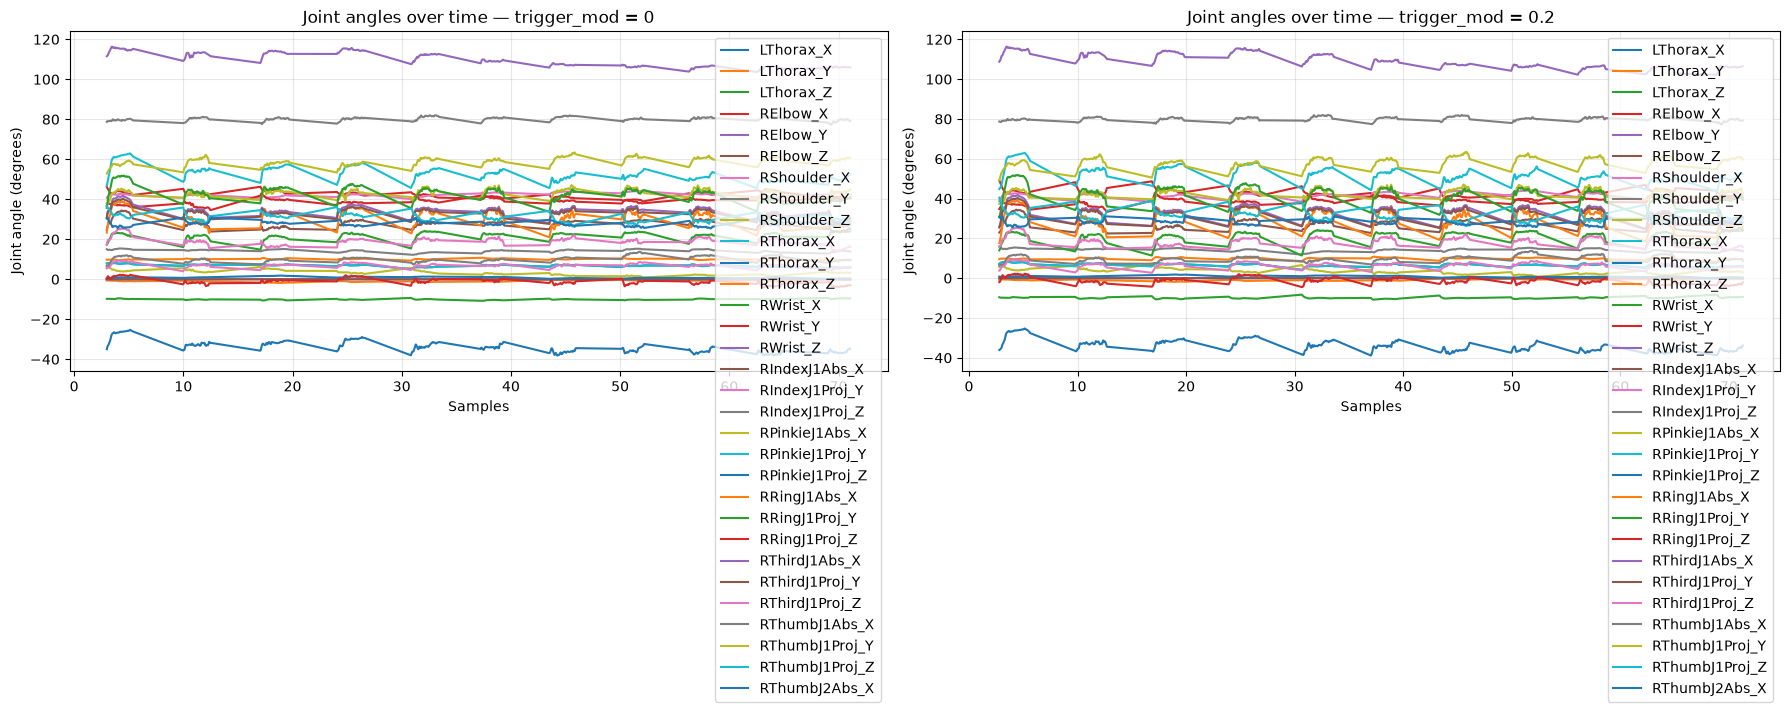

In [362]:
motion_data = get_motion_data()
motion_data_s2T = motion_data['sub-02']['ReaCyl']['motion_data']
motion_data_s2T_times = motion_data['sub-02']['ReaCyl']['time_labels']

motion_data02 = get_motion_data(trigger_mod = 0.2)
motion_data_s2T02 = motion_data02['sub-02']['ReaCyl']['motion_data']
motion_data_s2T02_times = motion_data02['sub-02']['ReaCyl']['time_labels']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- First plot ---
for joint_type in motion_data_s2T.index:
    axes[0].plot(
        motion_data_s2T_times,
        motion_data_s2T.loc[joint_type],
        label=joint_type
    )

axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Joint angle (degrees)")
axes[0].set_title("Joint angles over time — trigger_mod = 0")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# --- Second plot ---
for joint_type in motion_data_s2T02.index:
    axes[1].plot(
        motion_data_s2T02_times,
        motion_data_s2T02.loc[joint_type],
        label=joint_type
    )

axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Joint angle (degrees)")
axes[1].set_title("Joint angles over time — trigger_mod = 0.2")
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

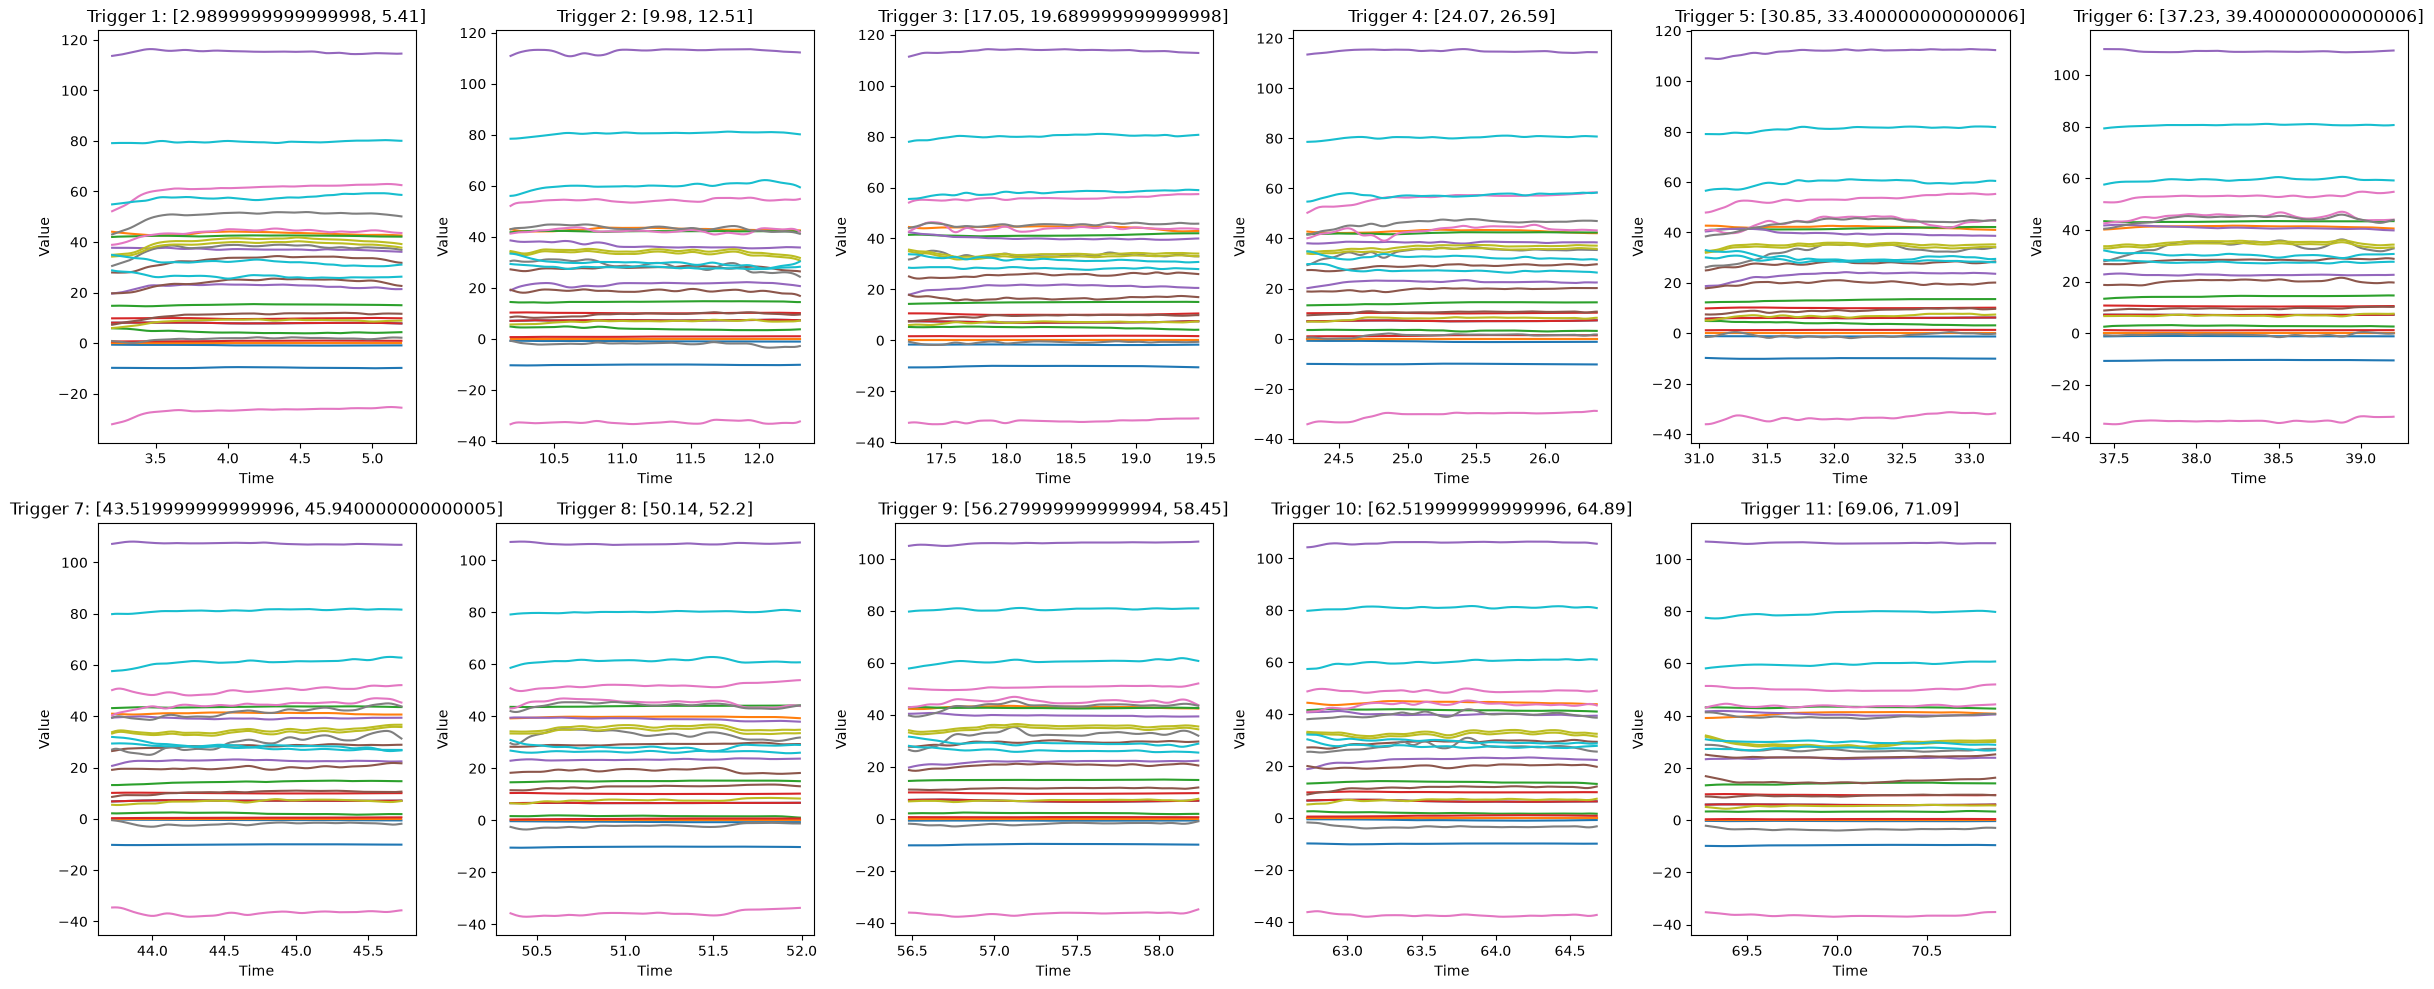

In [311]:
vicon_subset_s2T_triggerVals = vicon_subset02['sub-02']['ReaCyl']['trigger_vals']
vicon_subset_s2T = vicon_subset['sub-02']['ReaCyl']['vicon_data']
vicon_subset_s2T_jointTypes = vicon_subset_s2T.index
# --- Split trigger_vals into (start, end) pairs ---
trigger_pairs = [(vicon_subset_s2T_triggerVals[i], vicon_subset_s2T_triggerVals[i + 1]) 
                  for i in range(0, len(vicon_subset_s2T_triggerVals), 2)]

n_pairs = len(trigger_pairs)

# --- Set up grid: 2 rows, n_pairs/2 columns ---
n_cols = int(np.ceil(n_pairs / 2))
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 10), sharey=False)
axes = axes.flatten()  # makes indexing easy regardless of grid shape

# --- Color map for joint types (rows of vicon_subset) ---
joint_types = vicon_subset_s2T.index
colors = plt.cm.tab10(np.linspace(0, 1, len(joint_types)))

# --- Loop over each trigger bound, extract subset, and plot ---
for i, (start, end) in enumerate(trigger_pairs):
    ax = axes[i]
    
    # Select columns (time points) within this trigger bound
    # Assumes vicon_subset.columns are time values you can compare to start/end
    sub_df = vicon_subset_s2T.loc[:, (vicon_subset_s2T.columns >= start) & 
                                   (vicon_subset_s2T.columns <= end)]
    
    for joint, color in zip(vicon_subset_s2T_jointTypes, colors):
        ax.plot(sub_df.columns, sub_df.loc[joint], label=joint, color=color)
    
    ax.set_title(f"Trigger {i+1}: [{start}, {end}]")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")

# Hide any unused subplots (in case n_pairs is odd relative to grid)
for j in range(n_pairs, len(axes)):
    fig.delaxes(axes[j])

# Single shared legend for joint types
handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center', ncol=len(vicon_subset_s2T_jointTypes), 
#           bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

In [ ]:
"""
Segment and visualize emg data for each trigger bound identified by kinematic data.
 
Two graphs generated:
  1. A channel x time heatmap per repetition, with subplots from each repetition
  2. A per-channel small-multiples grid (one subplot per channel), with each
     repetition overlaid as a differently-colored trace within that channel's
     subplot; can indicate consistency across repititions
 
Both graphs plot the smoothed envelope (not the raw signal) for visualization purposes only.
 
Both views use time relative to each repetition's trigger onset (t - start_t)
so repetitions of differing duration/absolute timing line up for comparison.
"""

from scipy.signal import butter, filtfilt
 
 
def compute_linear_envelope(data, fs, lowpass_hz=4.0, order=4):
    """
    Compute a linear envelope of EMG data: full-wave rectify, then low-pass
    filter (zero-phase) to smooth out the noise and reveal the underlying
    contraction shape (ramp-up, plateau, ramp-down).
 
    Parameters:
    - data: np.array (n_channels x n_samples)
    - fs: sampling rate in Hz
    - lowpass_hz: cutoff frequency for the envelope smoothing filter.
          3-10 Hz is typical; lower = smoother but slower to track changes.
    - order: Butterworth filter order
 
    Returns:
    - envelope: np.array (n_channels x n_samples), same shape as data
    """
    data = np.asarray(data)
    rectified = np.abs(data)
 
    nyquist = fs / 2.0
    b, a = butter(order, lowpass_hz / nyquist, btype='low')
    envelope = filtfilt(b, a, rectified, axis=-1)
 
    return envelope
 
 
def _get_trigger_segments(sample_times, trigger_vals):
    """
    Parameters:
     - trigger_vals: array with start/end pairs of trigger bounds in s;
        Can be given as tuples or flattened
     - sample_times: array with sample times from data in s

     Returns:
     - segments: list containing (rep number, start time, end time) for each reptition
    """
    trigger_vals = np.asarray(trigger_vals).ravel() # flatten array, could also use .flatten(), no need to update original arry
    if trigger_vals.size % 2 != 0:
        raise ValueError("trigger_vals must contain an even number of values "
                          "(start/end pairs for each repetition).")
 
    n_reps = trigger_vals.size // 2
    segments = []
    for rep in range(n_reps):
        start_t = trigger_vals[2 * rep]
        end_t = trigger_vals[2 * rep + 1]
        mask = (sample_times >= start_t) & (sample_times <= end_t)
 
        if not np.any(mask):
            print(f"Warning: no samples found for repetition {rep + 1} "
                  f"({start_t}s - {end_t}s). Skipping.")
            continue
 
        segments.append((rep, start_t, end_t, mask))
 
    return segments
 
 
def plot_channel_heatmap(envelope, sample_times, trigger_vals,
                          n_cols=None, cmap_name='viridis',
                          share_color_scale=True, figsize=(16, 12)):
    """
    Plot a channel x time heatmap of the envelope for every repetition. 
    Rows = channels, columns = time (relative to trigger onset), color = envelope amplitude.

    A noisy channel will appear as bright (high amplitude) or irregular throughout entire period, including rest and movement stabilization.
    If the movement is stable, there should be consistency in rows which will increase/decrease in amplitude during stabilization start/end.
 
    Parameters:
    - envelope: array (dim: n_channels x n_samples)
        e.g. from compute_linear_envelope
    - sample_times: array of sample times in s (1 x n_samples)
    - trigger_vals: array of trigger bounds in s (kinematic trigger start/end pairs)
    - n_cols: number of subplot columns. Defaults to ceil(sqrt(n_reps)) for a roughly square layout.
    - cmap_name: matplotlib colormap for amplitude
    - share_color_scale: if True, all subplots use the same color scale
          (min/max envelope amplitude across all repetitions), making
          amplitude directly comparable across repetitions. If False, each
          subplot auto-scales to its own repetition.
    - figsize: (width, height) for the whole combined figure
 
    Returns:
    - (fig, axes): the combined figure and its array of subplot axes
    """
    envelope = np.asarray(envelope)
    n_channels = envelope.shape[0]
    segments = _get_trigger_segments(sample_times, trigger_vals)
    n_reps = len(segments)
 
    if n_cols is None:
        n_cols = math.ceil(math.sqrt(n_reps))
    n_rows = math.ceil(n_reps / n_cols)
 
    vmin = vmax = None
    if share_color_scale:
        all_vals = np.concatenate([envelope[:, mask].ravel() for _, _, _, mask in segments])
        vmin, vmax = all_vals.min(), all_vals.max()
 
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()
 
    im = None
    for idx, (rep, start_t, end_t, mask) in enumerate(segments):
        ax = axes_flat[idx]
        seg_times = sample_times[mask] - start_t  # time relative to onset
        seg_env = envelope[:, mask]
 
        im = ax.imshow(seg_env, aspect='auto', origin='lower', cmap=cmap_name,
                        extent=[seg_times[0], seg_times[-1], 0, n_channels],
                        vmin=vmin, vmax=vmax)
 
        ax.set_title(f"Rep {rep + 1} ({end_t - start_t:.2f}s)", fontsize=9)
        ax.tick_params(labelsize=7)
 
    # hide any unused subplot slots
    for idx in range(n_reps, len(axes_flat)):
        axes_flat[idx].axis('off')
 
    fig.supxlabel("Time relative to trigger onset (s)")
    fig.supylabel("Channel")
    fig.suptitle("EMG envelope amplitude by repetition")
 
    if im is not None:
        cbar = fig.colorbar(im, ax=axes, shrink=0.8)
        cbar.set_label("Envelope amplitude")
 
    return fig, axes
 
 
def plot_channel_grid(envelope, sample_times, trigger_vals,
                       n_rows=8, n_cols=8, share_y=True,
                       cmap_name='tab10', alpha=0.8, linewidth=0.8,
                       figsize=(20, 16)):
    """
    Plot a small-multiples grid of the envelope, one subplot per channel. 
    Each plot contains the envolopes from a single channel, across all repetitions in varying colors.
    Lookout for channels with irratic shapes or noticably large/small amplitudes across repitions.

 
    Parameters:
    - envelope: array (n_channels x n_samples), e.g. from compute_linear_envelope
    - sample_times: array of sample times in s (1 x n_samples)
    - trigger_vals: array of trigger bounds in s (start/end pairs)
    - n_rows, n_cols: grid layout. n_rows * n_cols must equal n_channels
    - share_y: if True, all subplots share the same y-axis scale, making it
          easy to spot channels with unusually high/low amplitude relative to
          others. Set False to let each channel auto-scale to its own shape.
    - cmap_name: matplotlib colormap used to assign each repetition a distinct
          color
    - alpha: opacity of each repetition's trace (lower = easier to see
          overlapping repetitions)
    - linewidth: line width for each repetition's trace
    - figsize: (width, height) for the whole combined figure
 
    Returns:
    - (fig, axes): the combined figure and its array of subplot axes
    """
    envelope = np.asarray(envelope)
    n_channels = envelope.shape[0]
 
    if n_rows * n_cols != n_channels:
        raise ValueError(f"n_rows * n_cols ({n_rows * n_cols}) must equal "
                          f"n_channels ({n_channels}).")
 
    segments = _get_trigger_segments(sample_times, trigger_vals)
    n_reps = len(segments)
 
    cmap = plt.get_cmap(cmap_name, max(n_reps, 1))
    colors = [cmap(i) for i in range(n_reps)]
 
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize,
                              sharex=True, sharey=share_y)
    axes_flat = np.asarray(axes).flatten()
 
    for ch in range(n_channels):
        ax = axes_flat[ch]
        for idx, (rep, start_t, end_t, mask) in enumerate(segments):
            seg_times = sample_times[mask] - start_t  # time relative to onset
            seg_env = envelope[ch, mask]
            ax.plot(seg_times, seg_env, color=colors[idx], alpha=alpha,
                    linewidth=linewidth, label=f"Rep {rep + 1}")
 
        ax.set_title(f"Ch {ch}", fontsize=8)
        ax.tick_params(labelsize=6)
 
    # single shared legend for repetitions, built from the first subplot
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', ncol=min(n_reps, 8), fontsize=8)
 
    fig.supxlabel("Time relative to trigger onset (s)")
    fig.supylabel("Envelope amplitude")
    fig.suptitle("EMG envelope by channel, all repetitions overlaid")
 
    return fig, axes
 
 
def visualize_trigger_bounds(data, sample_times, trigger_vals, fs,
                              lowpass_hz=4.0, heatmap_kwargs=None, grid_kwargs=None):
    """
    Convenience wrapper: compute the envelope once and generate reptition heatmaps and channel envelopes.
 
    Parameters:
    - data: np.array containing raw EMG data (n_channels x n_samples)
    - sample_times: array of sample times in s (1 x n_samples)
    - trigger_vals: array of trigger bounds in s (start/end pairs)
    - fs: sampling rate in Hz (e.g. 2048)
    - lowpass_hz: envelope smoothing cutoff, passed to compute_linear_envelope
    - heatmap_kwargs: optional dict of extra kwargs passed to plot_channel_heatmap
    - grid_kwargs: optional dict of extra kwargs passed to plot_channel_grid
          (n_rows/n_cols default to 8x8, assuming 64 channels)
 
    Returns:
    - dict with keys 'heatmap' and 'grid', each an (fig, axes) tuple as
          returned by plot_channel_heatmap / plot_channel_grid
    """
    data = np.asarray(data)
    envelope = compute_linear_envelope(data, fs=fs, lowpass_hz=lowpass_hz)
 
    heatmap_kwargs = heatmap_kwargs or {}
    grid_kwargs = grid_kwargs or {}
 
    heatmap_fig = plot_channel_heatmap(envelope, sample_times, trigger_vals,
                                        **heatmap_kwargs)
    grid_fig = plot_channel_grid(envelope, sample_times, trigger_vals,
                                  **grid_kwargs)
 
    return {'heatmap': heatmap_fig, 'grid': grid_fig}

In [ ]:
emg_data_HO1 = emg_subset_0['sub-02']['Trid']['emg_data']
emg_raw0 = emg_data_HO1.copy()

bound_times0 = emg_subset_0['sub-02']['Trid']['trigger_vals']
sample_times0 = emg_subset_0['sub-02']['Trid']['time_labels']

emg_graphs0 = visualize_trigger_bounds(emg_raw0, sample_times0, bound_times0, fs = 2000)
emg_graphs0['heatmap'][0].savefig('emg_heatmap0.png')
emg_graphs0['grid'][0].savefig("emg_grid0.png")

In [ ]:
emg_data_T02 = emg_subset_02['sub-02']['Trid']['emg_data']
emg_raw02 = emg_data_T02.copy()

bound_times02 = emg_subset_02['sub-02']['Trid']['trigger_vals']
sample_times02 = emg_subset_02['sub-02']['Trid']['time_labels']

emg_graphs02 = visualize_trigger_bounds(emg_raw02, sample_times02, bound_times02, fs = 2000)
emg_graphs02['heatmap'][0].savefig('emg_heatmap02.png')
emg_graphs02['grid'][0].savefig("emg_grid02.png")


In [378]:
%matplotlib qt
sys.path.insert(0, os.path.abspath(".."))
from src.utils.select_windows import select_windows
from src.utils.review_channels import review_channels

good_mask_path = "demo_good_mask.npy"
mask_path = "demo_mask.npy"
exclude_path = "demo_exclude.npy"

n_channels, n_samples = emg_data_HO1.shape[0], emg_data_HO1.shape[1]

review_channels(emg_data_HO1, good_mask_path, fs=fs, label="demo")

seed: auto RMS-outlier mask (64/64 good, bad [])


In [379]:
from scipy.interpolate import interp1d

def remove_spikes(emg, threshold_std=5):
    """
    Remove large spikes via simple thresholding and linear interpolation.
    
    Parameters
    ----------
    emg : ndarray, shape (n_channels, n_samples)
    threshold_std : float
        Number of standard deviations for threshold
    
    Returns
    -------
    emg_clean : ndarray
    spike_mask : ndarray, bool
    """
    emg_clean = emg.copy()
    spike_mask = np.zeros_like(emg, dtype=bool)
    
    for ch in range(emg.shape[0]):
        signal = emg[ch]
        threshold = threshold_std * np.std(signal)
        
        spikes = np.abs(signal) > threshold
        spike_mask[ch] = spikes
        
        if np.any(spikes):
            clean_idx = np.where(~spikes)[0]
            spike_idx = np.where(spikes)[0]
            
            if len(clean_idx) > 1:
                interp = interp1d(clean_idx, signal[clean_idx], 
                                  kind='linear', bounds_error=False, 
                                  fill_value='extrapolate')
                emg_clean[ch, spike_idx] = interp(spike_idx)
    
    return emg_clean, spike_mask


In [380]:
emg_clean0, spikes = remove_spikes(emg_raw0, threshold_std=5)

#plot emg before and after spike removal for first channel
# import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 6))        
# plt.subplot(2, 1, 1)
# plt.plot(emg_raw[0], label='Raw EMG', color='red')
# plt.title(f'Raw EMG Signal - Channel 0')
# plt.xlabel('Samples')
# plt.ylabel('Amplitude')
# plt.legend()

# plt.subplot(2, 1, 2)
# plt.plot(emg_clean[0], label='Cleaned EMG', color='blue')
# plt.title(f'Cleaned EMG Signal - Channel 0 ')
# plt.xlabel('Samples')
# plt.ylabel('Amplitude')
# plt.legend()

# plt.tight_layout()
# plt.show()

emg_graphs_clean0 = visualize_trigger_bounds(emg_clean0, sample_times0, bound_times0, fs = 2000)
emg_graphs_clean0['heatmap'][0].savefig('emg_heatmap_clean0.png')
emg_graphs_clean0['grid'][0].savefig("emg_grid_clean0.png")

In [381]:
n_channels, n_samples = emg_clean0.shape[0], emg_data_HO1.shape[1]

review_channels(emg_clean0, good_mask_path, fs=fs, label="demo")

seed: auto RMS-outlier mask (64/64 good, bad [])
SAVED: demo_good_mask.npy, 64/64 good


KeyboardInterrupt: 

In [382]:
select_windows(emg_clean0, fs, mask_path=mask_path, exclude_path=exclude_path, label="demo")

In [383]:

# on Windows Desktop:
#sys.path.append(os.path.abspath(r'C:\Users\annas\SynologyDrive\MedUniWien\Projects\NeuroClasp\Students\Liz Kalenteridis\MotorUnitSuite-main\src'))

# macOS:
sys.path.append(os.path.abspath('/Users/lizkal/Library/CloudStorage/SynologyDrive-Personal/SData_ReachGrasp/src'))

# Custom modules
from muniverse.algorithms.decompositionLK import decompose_cbss


# Windows Desktop
#algo_cfg = r"C:\Users\annas\SynologyDrive\MedUniWien\Projects\NeuroClasp\Students\Liz Kalenteridis\MotorUnitSuite-main\src\configs\cbss.json"
#with open(r"C:\Users\annas\SynologyDrive\MedUniWien\Projects\NeuroClasp\Students\Liz Kalenteridis\MotorUnitSuite-main\src\configs\cbss.json") as f:
#    algo_cfg = json.load(f)["Config"]

# macOS
with open('/Users/lizkal/Library/CloudStorage/SynologyDrive-Personal/SData_ReachGrasp/src/configs/cbss.json') as f:
   algo_cfg = json.load(f)["Config"]

#algo_cfg["sil_th"] = 0.7

results, metadata = decompose_cbss(
        data=emg_clean0,
        algorithm_config=algo_cfg,
        show_config=False, 
)




[INFO] Extending signals by factor 16...

STARTING CBSS DECOMPOSITION
Max iterations: 100, Silhouette threshold: 0.850, CoV threshold: 0.350

FR peel-off enabled
0: NO PEEL-OFF - Silhouette: 0.985, CoV: 0.756, FR: 0.24 Hz, Spikes: 3
Refinement loop for source 1 (initial Sil: 0.729, CoV: 0.587, Spikes: 213)
FR peel-off enabled
1: NO PEEL-OFF - Silhouette: 0.812, CoV: 0.587, FR: 17.21 Hz, Spikes: 213
Refinement loop for source 2 (initial Sil: 0.858, CoV: 0.591, Spikes: 202)
FR peel-off enabled
2: NO PEEL-OFF - Silhouette: 0.788, CoV: 0.591, FR: 15.92 Hz, Spikes: 197
FR peel-off enabled
3: NO PEEL-OFF - Silhouette: 0.992, CoV: 0.572, FR: 0.40 Hz, Spikes: 5
FR peel-off enabled
4: NO PEEL-OFF - Silhouette: 0.917, CoV: 0.756, FR: 0.24 Hz, Spikes: 3
FR peel-off enabled
5: NO PEEL-OFF - Silhouette: 0.897, CoV: 0.735, FR: 0.73 Hz, Spikes: 9
FR peel-off enabled
6: NO PEEL-OFF - Silhouette: 1.000, CoV: inf, FR: 0.08 Hz, Spikes: 1
FR peel-off enabled
7: NO PEEL-OFF - Silhouette: 0.939, CoV: 0.692,

In [365]:
results["spikes"].keys()

dict_keys([0, 1])